In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('E-commerce Dataset.csv')

In [3]:
df.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


In [4]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Time'] = pd.to_datetime(df['Time'])

/tmp/ipykernel_468/2041229924.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_Date           51290 non-null  datetime64[ns]
 1   Time                 51290 non-null  datetime64[ns]
 2   Aging                51289 non-null  float64       
 3   Customer_Id          51290 non-null  int64         
 4   Gender               51290 non-null  object        
 5   Device_Type          51290 non-null  object        
 6   Customer_Login_type  51290 non-null  object        
 7   Product_Category     51290 non-null  object        
 8   Product              51290 non-null  object        
 9   Sales                51289 non-null  float64       
 10  Quantity             51288 non-null  float64       
 11  Discount             51289 non-null  float64       
 12  Profit               51290 non-null  float64       
 13  Shipping_Cost        51289 non-

### Order Date and Time are in datetime dtype so it is fine and rest of the data dtype are also good .....so lets find the no. of null values

In [6]:
df.isnull().sum()

,0
Order_Date,0
Time,0
Aging,1
Customer_Id,0
Gender,0
Device_Type,0
Customer_Login_type,0
Product_Category,0
Product,0
Sales,1


### Only less no.of values are missing in each columns so its better to drop

In [7]:
df.dropna(inplace=True)

### Also better to drop dulpicate value to get better model

In [8]:
df.drop_duplicates(inplace= True)

In [9]:
df = df.reset_index()

## Univariate Analysis

### Lets check which gender has made more orders

In [10]:
df[['Gender']].value_counts()

,count
Gender,
Male,28132
Female,23150


### There is 1 value with female gender as fem so I am changing its title

In [11]:
df[['Gender']] = df[['Gender']].replace('Fem','Female')

In [12]:
df['Gender'].value_counts()

,count
Gender,
Male,28132
Female,23150


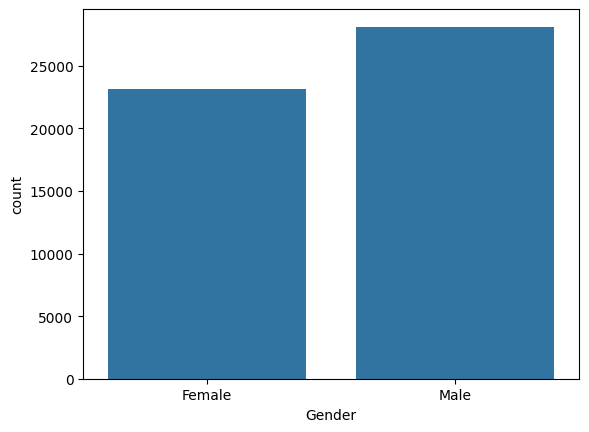

In [13]:
sns.countplot(data=df, x='Gender')
plt.show()

### Observation :
      

*   So male make more orders compared to female




### Let's check on what device the customers make more orders

In [14]:
df[['Device_Type']].value_counts()

,count
Device_Type,
Web,47624
Mobile,3658


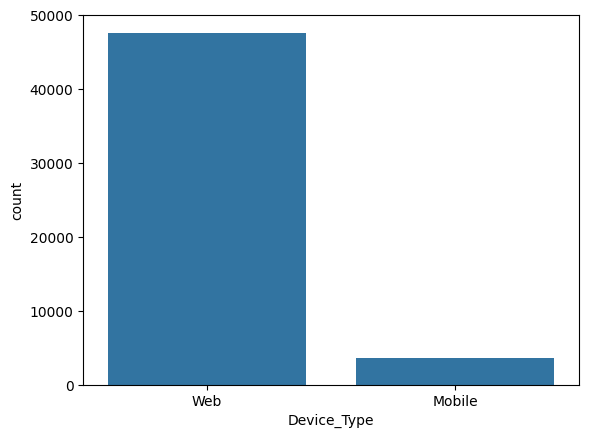

In [15]:
sns.countplot(data=df, x= 'Device_Type')
plt.show()

### Observation :
*   So people make more orders using web and not mobile




## Lets which product category made more sales

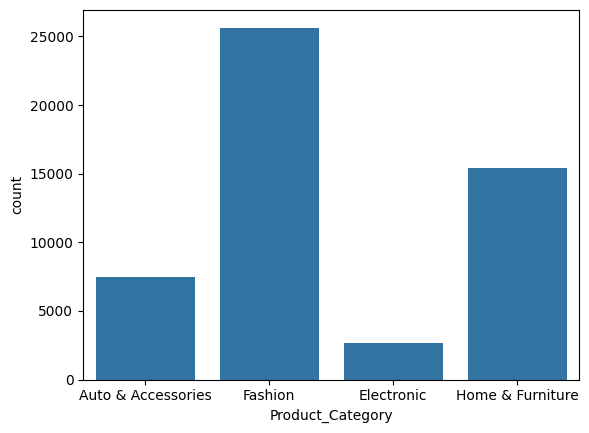

In [16]:
sns.countplot(data = df , x='Product_Category')
plt.show()

### Okay Fashion make more sales in the e commerece platfrom

In [17]:
data = df['Payment_method'].value_counts().reset_index()
data

,Payment_method,count
0,credit_card,38131
1,money_order,9628
2,e_wallet,2789
3,debit_card,733
4,not_defined,1


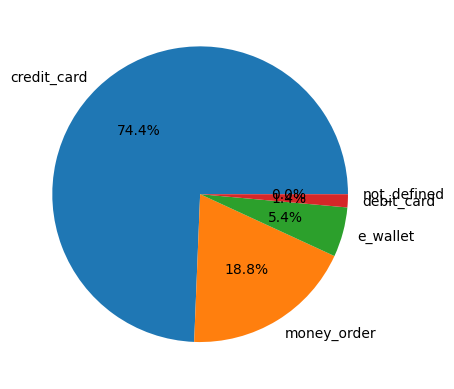

In [18]:
plt.pie(data['count'],labels = data['Payment_method'], autopct='%1.1f%%')
plt.show()

### Nealy 75% of the customer use credit card to purchase

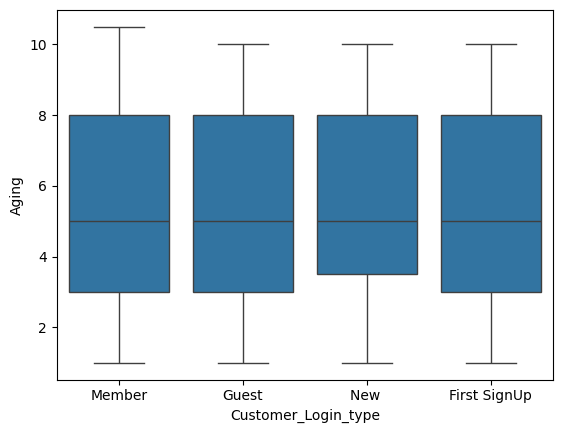

In [19]:
sns.boxplot(data = df , y='Aging', x ='Customer_Login_type')
plt.show()

### So basically they take min of 1 days to deliver and take average of 5 day to deliver the product irrespective of the login type of the customers

## Bivariate Analysis

In [20]:
df1 = df[['Product_Category','Profit']].groupby('Product_Category')['Profit'].sum().reset_index()
df1

,Product_Category,Profit
0,Auto & Accessories,483471.5
1,Electronic,174190.6
2,Fashion,2072623.9
3,Home & Furniture,880058.9


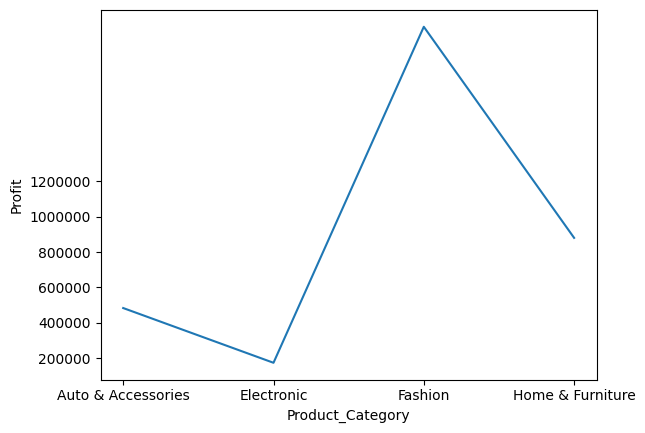

In [21]:
ax = sns.lineplot(data = df1 , x='Product_Category', y='Profit')
plt.yticks(range(200000,1400000,200000))
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### So Fashion product gives more profits

### Lets check Gender Distribution by Product_Category

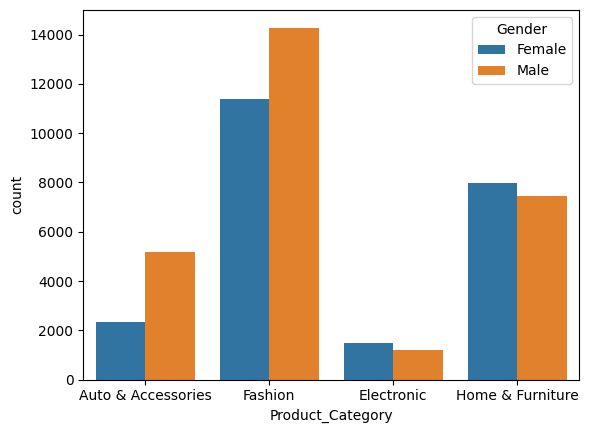

In [22]:
sns.countplot(data=df , x='Product_Category',hue='Gender')
plt.show()

### Observation :                   
*   Even in fashion product men were the one who purchased more and only in Electronis product women bought more than male but not significantly higher




In [23]:
df['Order_Date'].dt.year.value_counts()

,count
Order_Date,
2018,51282


### Since the data have only the year 2018 lets analysis the data based on months

In [24]:
df['Month'] = df['Order_Date'].dt.month_name()
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

In [25]:
df2 = df[['Month','Sales']].groupby('Month')['Sales'].sum().reset_index()
df2


/tmp/ipykernel_468/320842999.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2 = df[['Month','Sales']].groupby('Month')['Sales'].sum().reset_index()


,Month,Sales
0,January,379627.0
1,February,332495.0
2,March,435502.0
3,April,596990.0
4,May,824362.0
5,June,642501.0
6,July,809974.0
7,August,664245.0
8,September,738303.0
9,October,743137.0


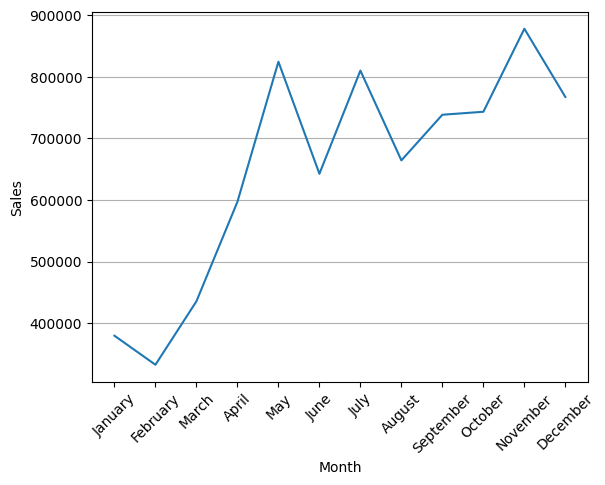

In [26]:
sns.lineplot(data = df2 , x='Month', y='Sales')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### There is high sales on April to May , July to August and November to December

#### relationship between sales vs profit

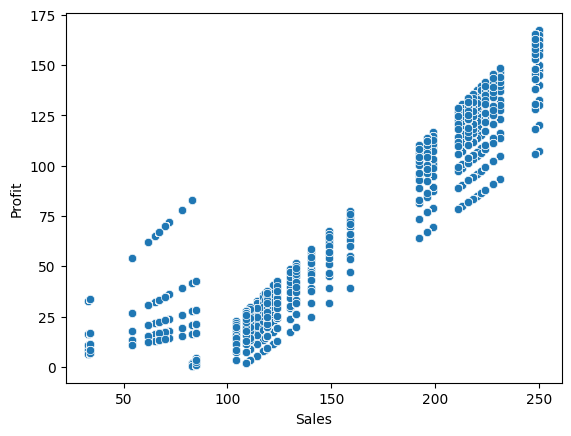

In [27]:
sns.scatterplot(data = df , x='Sales', y ='Profit')
plt.show()

#### for higher sales means higher profits for the platform

## Multivariate Analysis

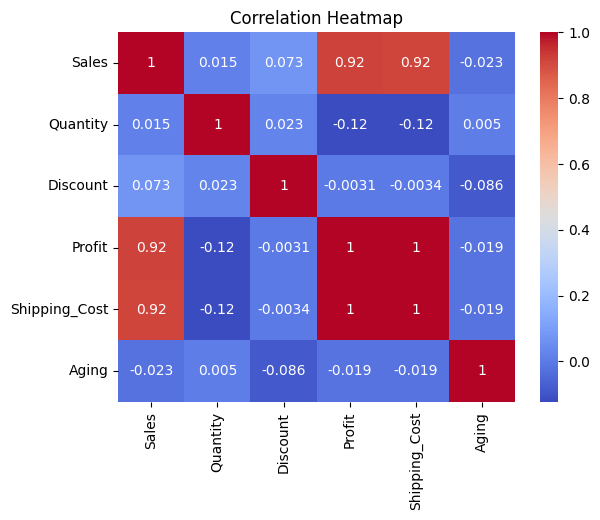

In [28]:
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Aging']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Sales and Profit are highly corelated with value 0.92 and profit and shipping cost are perfect 1 ...so it is better one column before feedding it into model to avoid overfitting and multicollinarity

## Key Findings:

1.   Male customers where the one who make large orders even in Fashion products
2.   Out of all the category, Fashion is the with highest sale
1.   75 % Customers use credit card to make the purchase
2.   Average of 4 to 5 days where taken to deliver the order irrespective of login type of customers
1.   Between October to November there is a huge sale and in april to may and june to july there is a spike in sales and Feb got the  lowest sales
2.   From the heatmap we can say that high Sales means high profit , and also we can come to conclusion that in this case discount is not highly related with profit







**Right now let jump into predicting the profit by using machine learning**

In [29]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [31]:
X = df[['Sales','Quantity','Discount','Shipping_Cost','Aging']]
y = df['Profit']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
lr = LinearRegression()

lr_params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr_grid = GridSearchCV(
    lr,
    lr_params,
    cv=5
)

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

print("Best Linear Regression Parameters:")
print(lr_grid.best_params_)

Best Linear Regression Parameters:
{'fit_intercept': True, 'positive': True}


In [34]:
lr_pred = best_lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 0.254285586749521
Linear Regression RMSE: 0.29534940490758627


**Random Forest**

In [35]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': 20, 'n_estimators': 200}


In [36]:
rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 0.001247499986354264
Random Forest RMSE: 0.026518823267822192


In [38]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

results

,Model,MAE,RMSE
0,Linear Regression,0.254286,0.295349
1,Random Forest,0.001247,0.026519


In [39]:
best_model = results.loc[results['RMSE'].idxmin()]

print("Best Performing Model:", best_model["Model"])

Best Performing Model: Random Forest


In [40]:
import joblib

joblib.dump(best_rf, "profit_prediction_model.pkl")

['profit_prediction_model.pkl']